In [ ]:
pip install lightgbm

In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression,Ridge,Lasso
from sklearn.model_selection import cross_val_score,GridSearchCV,RandomizedSearchCV,train_test_split
from sklearn.metrics import f1_score,accuracy_score,classification_report,confusion_matrix,roc_auc_score, auc,roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier,AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from mypipes import *

import warnings
warnings.filterwarnings('ignore') # ignore the warnings.


import matplotlib.pyplot as plt
import seaborn as sb
def report(results, n_top=3):
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.6f} (std: {1:.6f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

def Threshold_Finder(Y_test,Y_predict):
    I = []
    roc_ = []
    for i in np.linspace(0.01,1,1000):
        Y_predict = Y_predict_prob[:,1] > i
        roc = f1_score(Y_test,Y_predict)
        I.append(i)
        roc_.append(roc)
    Temp = I[roc_.index(max(roc_))]
    return Temp

In [ ]:
train_data = r'paydayloan_collections.csv'
#test_data = r''

train_data = pd.read_csv(train_data)
#test_data = pd.read_csv(test_data)

In [ ]:
p1 = pdPipeline([
    ('columns_selection',VarSelector(['var1','var2','var9','var10','var11','var13','var17','var19','var23','var29'])),
    ('data_impute',DataFrameImputer()),
    ('get_dummy',get_dummies_Pipe())
])
temp = pd.DataFrame(data = p1.fit_transform(train_data),columns = p1.get_feature_names())

train_data = pd.concat([train_data,temp],axis = 1)

In [ ]:
Y_train = train_data['payment']
Y_train = pd.DataFrame(data = Y_train , columns = ['payment'] )
train_data.drop(columns = ['payment'],inplace = True)
X_train = train_data
X_train.drop(['var1','var2','var9','var10','var11','var13','var17','var19','var23','var29'],inplace = True,axis = 1)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 62 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   var3      30000 non-null  float64
 1   var4      30000 non-null  float64
 2   var5      30000 non-null  float64
 3   var6      30000 non-null  float64
 4   var7      30000 non-null  float64
 5   var8      30000 non-null  float64
 6   var12     30000 non-null  float64
 7   var14     30000 non-null  float64
 8   var15     30000 non-null  float64
 9   var16     30000 non-null  float64
 10  var18     30000 non-null  float64
 11  var20     30000 non-null  float64
 12  var21     30000 non-null  float64
 13  var22     30000 non-null  float64
 14  var24     30000 non-null  float64
 15  var25     30000 non-null  float64
 16  var26     30000 non-null  float64
 17  var27     30000 non-null  float64
 18  var28     30000 non-null  float64
 19  var30     30000 non-null  float64
 20  var1_qw   30000 non-null  in

In [ ]:
Y_train = (Y_train['payment'] == 'Success').astype(int)
Y_train

,payment
0,1
1,0
2,0
3,1
4,1
...,...
29995,1
29996,0
29997,0
29998,1


In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X_train, Y_train, test_size=0.2, random_state=1)

In [ ]:
%%time
lgb_model = LGBMClassifier()
lgb_model_cv_scores = cross_val_score(lgb_model,X_train,Y_train,cv=5,scoring='roc_auc',n_jobs=-1)
lgb_model_cv_scores.mean()

CPU times: user 109 ms, sys: 30.9 ms, total: 140 ms
Wall time: 17.8 s


np.float64(0.8891084378389884)

In [ ]:
lgb_model.fit(X_train,Y_train)
Y_predict = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 8986, number of negative: 15014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003113 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5184
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.374417 -> initscore=-0.513315
[LightGBM] [Info] Start training from score -0.513315


In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3411,  330],
       [ 416, 1843]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3741
           1       0.85      0.82      0.83      2259

    accuracy                           0.88      6000
   macro avg       0.87      0.86      0.87      6000
weighted avg       0.88      0.88      0.88      6000



In [ ]:
Y_predict_prob = lgb_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.41432432432432437)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      3741
           1       0.83      0.84      0.84      2259

    accuracy                           0.88      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.88      0.88      0.88      6000



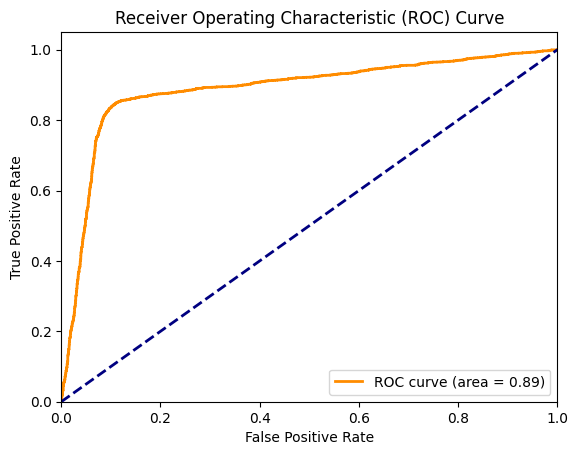

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, lgb_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Define the parameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 100],
    'max_depth': [-1, 5, 10, 15],
    'min_child_samples': [10, 20, 50, 100],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0],
}

In [ ]:
# Initialize the LGBMClassifier
lgbm = LGBMClassifier(random_state=1)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=lgbm, param_distributions=param_grid,
                                   n_iter=50, scoring='roc_auc', cv=5, n_jobs=-1, random_state=1)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, Y_train)

[LightGBM] [Info] Number of positive: 8986, number of negative: 15014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5184
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.374417 -> initscore=-0.513315
[LightGBM] [Info] Start training from score -0.513315


RandomizedSearchCV(cv=5, estimator=LGBMClassifier(random_state=1), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [-1, 5, 10, 15],
                                        'min_child_samples': [10, 20, 50, 100],
                                        'n_estimators': [100, 200, 500, 1000],
                                        'num_leaves': [20, 31, 50, 100],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=1, scoring='roc_auc')

In [ ]:
# Print the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best ROC-AUC score found: ", random_search.best_score_)

# Evaluate the model with the best parameters on the test set
best_lgbm_model = random_search.best_estimator_
Y_predict_tuned = best_lgbm_model.predict(X_test)
Y_predict_prob_tuned = best_lgbm_model.predict_proba(X_test)

Best parameters found:  {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 100, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best ROC-AUC score found:  0.8905974790424148



Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3741
           1       0.85      0.81      0.83      2259

    accuracy                           0.87      6000
   macro avg       0.87      0.86      0.87      6000
weighted avg       0.87      0.87      0.87      6000


ROC AUC Score for Tuned Model:  0.8859274358208852


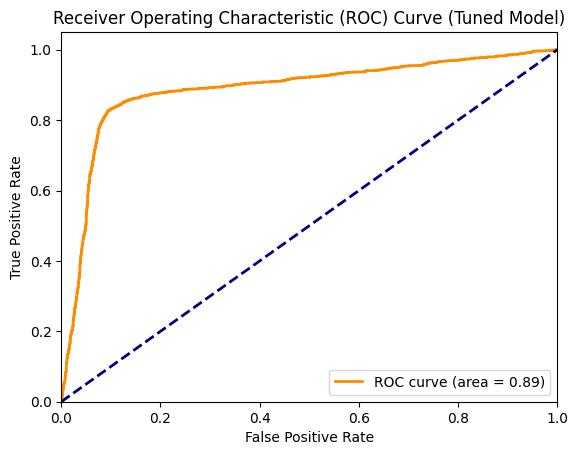

In [ ]:
# Print classification report and ROC AUC score for the tuned model
print("\nClassification Report for Tuned Model:")
print(classification_report(Y_test, Y_predict_tuned))

roc_auc_tuned = roc_auc_score(Y_test, Y_predict_prob_tuned[:, 1])
print("\nROC AUC Score for Tuned Model: ", roc_auc_tuned)

# ROC Curve for the tuned model
fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(Y_test, Y_predict_prob_tuned[:,1])

plt.figure()
plt.plot(fpr_tuned, tpr_tuned, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_tuned)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Tuned Model)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import joblib

# Save the best model
joblib.dump(best_lgbm_model, 'tuned_lgbm_model.pkl')
print("Tuned LightGBM model saved successfully as 'tuned_lgbm_model.pkl'")

Tuned LightGBM model saved successfully as 'tuned_lgbm_model.pkl'


In [ ]:
# Load the saved model
loaded_model = joblib.load('tuned_lgbm_model.pkl')

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
# Print the classification report for the predictions made with the loaded model
print("\nClassification Report for Loaded Model:")
print(classification_report(Y_test, Y_predict_loaded))


Classification Report for Loaded Model:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3741
           1       0.85      0.81      0.83      2259

    accuracy                           0.87      6000
   macro avg       0.87      0.86      0.87      6000
weighted avg       0.87      0.87      0.87      6000



In [ ]:
train_data.describe()

,var3,var4,var5,var6,var7,var8,var12,var14,var15,var16,...,var23_tf,var23_ub,var23_qu,var23_ri,var23_fe,var23_da,var23_cz,var23_sy,var23_yv,var29_ev
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,3.018848,13.941943,19.981561,8.009453,9.110358,5.993785,7.020662,2.007760,17.118747,10.919426,...,0.259833,0.210500,0.164400,0.130667,0.091567,0.065267,0.042133,0.022600,0.010633,0.797767
std,3.004458,14.028019,19.866781,8.013395,8.976009,6.035204,7.004504,2.001967,16.900037,10.977430,...,0.438550,0.407671,0.370644,0.337041,0.288418,0.247000,0.200897,0.148627,0.102570,0.401672
min,-8.190000,-43.660000,-55.100000,-23.630000,-27.580000,-17.940000,-29.340000,-5.500000,-54.270000,-34.510000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.990000,4.450000,6.520000,2.550000,3.050000,1.910000,2.320000,0.650000,5.677500,3.470000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,3.040000,13.920000,19.980000,8.010000,9.170000,5.960000,7.020000,2.000000,17.120000,10.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,5.040000,23.520000,33.452500,13.430000,15.152500,10.050000,11.760000,3.370000,28.620000,18.310000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,15.160000,76.780000,107.080000,44.330000,48.390000,29.100000,37.370000,10.090000,81.410000,60.720000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
